In [41]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from scipy import linalg as LA
import random
import numpy.matlib
import kwant
import tinyarray
import multiprocessing as mp
import os
from tqdm import tqdm
import helpers as hp
from pathlib import Path
from config import PathConfigs
import scipy.sparse.linalg as sla
import multiprocessing as mp
from functools import partial
from scipy.signal import find_peaks
import itertools as itr

#pauli matrices
sigma_0 = tinyarray.array([[1, 0], [0, 1]])
sigma_x = tinyarray.array([[0, 1], [1, 0]])
sigma_y = tinyarray.array([[0, -1j], [1j, 0]])
sigma_z = tinyarray.array([[1, 0], [0, -1]])

In [42]:
def build_system_closed(t, mu, mu_n, gamma, Delta0, V_z, alpha, Ls, mu_leads, barrier_l, barrier_r, Vdisx = None, a = 1):
    # Strictly the SM-SC region (Open Boundary Conditions, no barriers/leads)
    
    syst = kwant.Builder()
    lat = kwant.lattice.square(a, norbs=4)
    
    Z = Delta0/(Delta0 + gamma)
    
    mu_s = np.zeros(Ls)
    if Vdisx is None:
        Vdisx  = np.zeros_like(mu_s)
        
    for i in range(Ls):
        mu_s[i] = mu + Vdisx[i]    

    # 1. Superconductor (Renormalized) - Only region left
    for i in range(Ls):
        syst[lat(i, 0)] = Z * (2 * t - mu_s[i]) * np.kron(sigma_z, sigma_0) \
                          + Z * V_z * np.kron(sigma_0, sigma_x) \
                          + Z * gamma * np.kron(sigma_x, sigma_0) 
        
        if i > 0: 
            # Uniform hopping throughout the pure SM-SC wire (no interface z_hop needed)
            syst[lat(i, 0), lat(i-1, 0)] = Z * (-t * np.kron(sigma_z, sigma_0) + 1j*alpha * np.kron(sigma_z, sigma_y))
    
    return syst.finalized()

In [43]:
dirname = Path(PathConfigs.DATA/"mu_fix"/"vdis2_nb_strdis")
all_params = np.load(Path(dirname, 'all_params.npz'))

Vz_var = all_params['Vz_var']

V0 = all_params['V0']

Vdisx = hp.np_load_wrapped("Vdisx", dirname)*V0

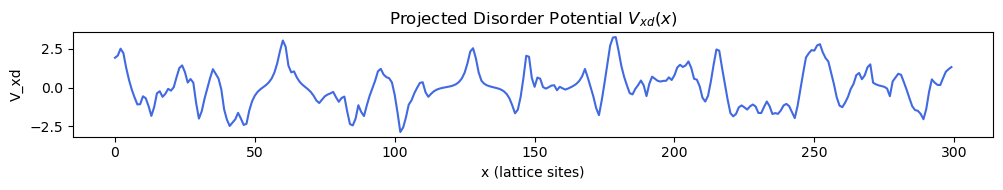

ΔVd = 0.0000
sqrt[<Vxd²>] = 1.2000


In [44]:
Nx = len(Vdisx)
plt.figure(figsize=(10, 2))
plt.plot(np.arange(Nx), Vdisx, color='royalblue')
plt.xlabel("x (lattice sites)")
plt.ylabel("V_xd")
plt.title("Projected Disorder Potential $V_{xd}(x)$")
plt.gca().set_aspect('auto')
plt.tight_layout()
plt.show()

# mean and variance
DeltaVd = np.mean(Vdisx)
VarVd = np.mean(Vdisx**2)
print(f"ΔVd = {DeltaVd:.4f}")
print(f"sqrt[<Vxd²>] = {np.sqrt(VarVd):.4f}")

In [45]:

#### constants: 
hbar = 6.58211899e-16  # eV·s
m0   = 9.10938291e-31  # kg
e0 = 1.602176487e-19   # C
eta_m = (hbar ** 2 * e0) * (1e20)/m0 # hbar^2/m0 in eV A^2
mu_B =  5.7883818066e-2  #in meV/T
meVpK = 8.6173325e-2 # Kelvin into meV 

In [46]:
Ls = 300 # wire length

Ln = 0 #length of normal region. See Dourado 2023
a0 = 100 # unit cell in A
ms = 0.023 # effective mass

t = 1000 * eta_m/(2 * a0**2 * ms) # hopping in meV
alpha = 140.0/a0 # Rashba SOC

Delta0= 0.3 # parent SC gap
gamma = 0.2 # SM-SC coupling strength in meV
Delta = Delta0 * gamma /(Delta0 + gamma) #induced gap

mu_leads = t # lead chemical potential (meV)

barrier0 = 5 #barrier energy (meV)

V0 = 1.2#10.5 * Delta 

Upoints = 20 
num_engs = 101  

mu_n = 0.0

mu_max = 4.0
mu_min = 1
mu_rng = mu_max - mu_min
mu_dist = 0.04 #spacing between points
Nmu = int(mu_rng/mu_dist) #total number of paramter space points for mu
mu_var = np.linspace(mu_min, mu_max, Nmu)

Vz_max = 1.3
Vz_min = 0.75
Vz_rng = Vz_max - Vz_min
Vz_dist = 0.02 #spacing between points
Nvz = int(Vz_rng/Vz_dist)
Vz_var = np.linspace(Vz_min, Vz_max, Nvz) 


params_list = [pms for pms in itr.product(mu_var, Vz_var)]
params_list = [[i, pms[0], pms[1]] for i, pms in enumerate(params_list)]


barrier_arr = np.linspace(barrier0, 40*barrier0, Upoints)
energies = np.linspace(-0.5, 0.5, num_engs)


num_eigenvalues = 22 #number of eigenvalues to calculate in the low energy spectra, so 10 above and below the MZMs in this case

In [53]:
target_mu = 0.482142857
Vz_var = np.linspace(0.02,1.3,50)
spectrum = np.zeros(shape = (len(Vz_var), 22))
for i in tqdm(range(len(Vz_var))):
    V_z = Vz_var[i]
    syst = build_system_closed(t, target_mu, mu_n, gamma, Delta0, V_z, alpha, Ls, mu_leads, barrier0, barrier0, Vdisx = Vdisx)

    spectrum[i,:]=hp.calc_spectrum(syst)

100%|██████████| 50/50 [00:42<00:00,  1.17it/s]


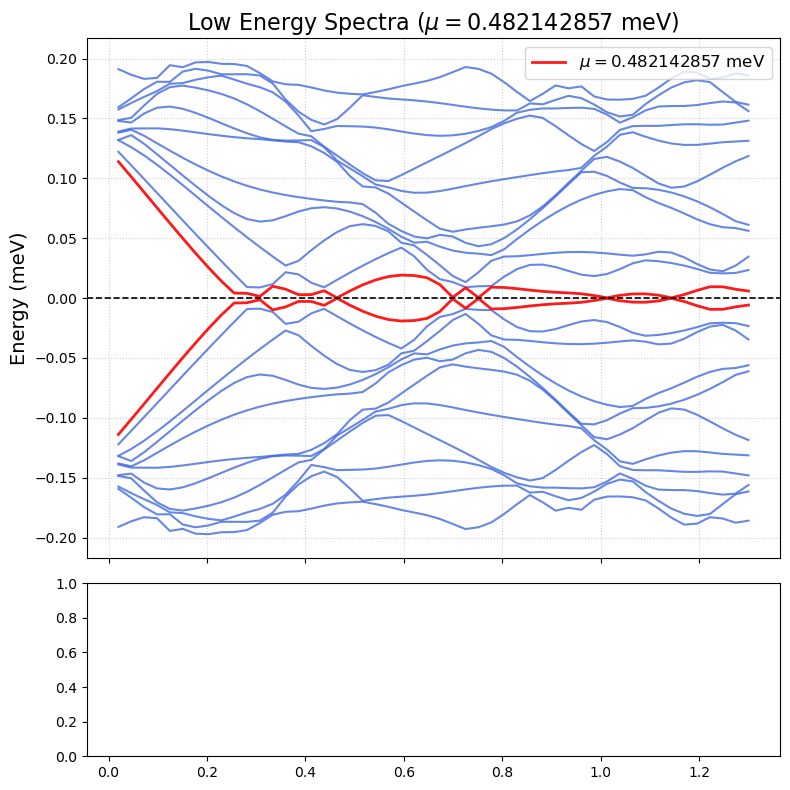

In [54]:


plot_vz = Vz_var

plot_spectra = spectrum

# 6. Create the Figure with 2 Subplots
# gridspec_kw={'height_ratios': [3, 1]} makes the top plot 3x taller than the bottom
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, 
    figsize=(8, 8), 
    dpi=100, 
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]} 
)

# ---------------------------------------------------------
# TOP PLOT (ax1): Energy Spectrum
# ---------------------------------------------------------
# Plot the bulk states in standard blue
ax1.plot(plot_vz, plot_spectra[:, :10], color='royalblue', alpha=0.8, linewidth=1.5)
ax1.plot(plot_vz, plot_spectra[:, 12:], color='royalblue', alpha=0.8, linewidth=1.5)

# Plot the two states closest to E=0 in red. 
ax1.plot(plot_vz, plot_spectra[:, 10:12], color='red', alpha=0.9, linewidth=2.0, label=rf"$\mu = {target_mu}$ meV")

ax1.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax1.set_ylabel("Energy (meV)", fontsize=14)
ax1.set_title(f"Low Energy Spectra ($\mu = {target_mu}$ meV)", fontsize=16)
ax1.grid(True, linestyle=':', alpha=0.6)

# Fix the legend so the mu label only appears once
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=12)


# Clean up layout so labels don't overlap
plt.tight_layout()
plt.show()